In [ ]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

# Single and double-positive neuron proportions

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [1]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04a_neurons"
adata_path = input_dir / "scanvi_scvi_adata.h5ad"
bdata_path = input_dir / "seurat_scvi_adata.h5ad"

In [6]:
adata = sc.read_h5ad(adata_path)
adata = sc.read_h5ad(bdata_path)

In [21]:
def plot_seurat_for_subset(adata_subset, title, color="steelblue", horizontal=True):
    """
    adata_subset : an AnnData object (e.g., neuron-only)
    """
    # Extract seurat_labels from the subset as a DataFrame
    df = adata_subset.obs[["seurat_labels"]].copy()

    # Remove missing values just in case
    df = df.dropna(subset=["seurat_labels"])

    plot_bar_from_labels(
        df,
        "seurat_labels",
        title,
        horizontal=horizontal,
        color=color
    )

In [22]:
neuron_adata = adata[adata.obs["class_seurat"] == "Neuron"].copy()

# Remove unused categories from all categorical columns
for col in neuron_adata.obs.select_dtypes(include="category").columns:
    neuron_adata.obs[col] = neuron_adata.obs[col].cat.remove_unused_categories()
    
neuron_adata.obs.class_seurat.value_counts()

class_seurat
Neuron    63591
Name: count, dtype: int64

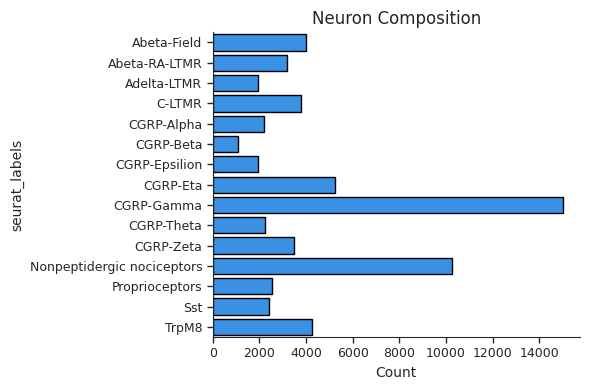

In [23]:
plot_seurat_for_subset(
    neuron_adata,
    title="Neuron Composition",
    color="dodgerblue",
    horizontal=True
)

In [27]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max,confidence,scanvi_class,seurat_class,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,class_seurat
aaadagcf-1,aaadagcf-1,772.174255,2206.725830,2492,0,0,0,0,0,2492.0,...,0.0,0.000000,0.978490,NaN,Neuron,Neuron,False,False,False,Neuron
aaaihgjh-1,aaaihgjh-1,769.295227,2240.681641,4902,0,0,1,0,0,4902.0,...,0.0,0.000000,0.831561,NaN,Neuron,Neuron,False,False,False,Neuron
aabcohae-1,aabcohae-1,733.544678,2249.933838,2474,0,0,0,0,0,2474.0,...,0.0,0.000000,0.980109,NaN,Neuron,Neuron,False,False,False,Neuron
aabdncpn-1,aabdncpn-1,749.500977,2226.913574,2246,0,0,0,0,0,2246.0,...,0.0,0.000000,0.933226,NaN,Neuron,Neuron,False,False,False,Neuron
aabkbaii-1,aabkbaii-1,712.913574,2282.130615,262,0,0,0,0,0,262.0,...,0.0,0.000000,0.778260,NaN,Non-neuron,Non-neuron,False,False,False,Non-neuron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oinbodhi-1,oinbodhi-1,2703.527100,3917.642578,120,0,0,0,0,0,120.0,...,0.0,0.000000,0.804818,NaN,Neuron,Neuron,False,False,False,Neuron
oinfomah-1,oinfomah-1,2485.987061,3865.038818,52,0,0,0,0,0,52.0,...,0.0,0.592846,0.592846,NaN,Neuron,Non-neuron,False,False,False,Non-neuron
oinmpaga-1,oinmpaga-1,2414.437012,3872.206543,54,0,0,0,0,0,54.0,...,0.0,0.000000,1.000000,NaN,Non-neuron,Non-neuron,False,False,False,Non-neuron
oiolohdm-1,oiolohdm-1,2665.772217,3808.245850,60,0,0,0,0,0,60.0,...,0.0,0.000000,1.000000,NaN,Non-neuron,Non-neuron,False,False,False,Non-neuron


In [24]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1) Restrict to neurons only
# ---------------------------------------------
neuron_adata = adata[adata.obs["class_seurat"] == "Neuron"].copy()

egfp_hi = neuron_adata.obs["EGFP_Seq1_hi"]
td_hi   = neuron_adata.obs["dTomato_Seq2_hi"]

# ---------------------------------------------
# 2) Compute true dTomato-only vs dual inside neurons
# ---------------------------------------------
dual_hi_neuron   = egfp_hi & td_hi           # EGFP+ AND dTomato+
td_only_neuron   = td_hi & ~egfp_hi          # dTomato+ AND NOT EGFP+

# ---------------------------------------------
# 3) Denominator = all dTomato+ neurons
# ---------------------------------------------
total_td_neuron = (dual_hi_neuron | td_only_neuron).sum()

print("Total dTomato+ Neurons:", total_td_neuron)
print("Dual-positive Neurons:", dual_hi_neuron.sum())
print("dTomato-only Neurons:", td_only_neuron.sum())

Total dTomato+ Neurons: 132
Dual-positive Neurons: 22
dTomato-only Neurons: 110


In [28]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1) Restrict to neurons only
# ---------------------------------------------
neuron_adata = adata[adata.obs["scanvi_class"] == "Neuron"].copy()

egfp_hi = neuron_adata.obs["EGFP_Seq1_hi"]
td_hi   = neuron_adata.obs["dTomato_Seq2_hi"]

# ---------------------------------------------
# 2) Compute true dTomato-only vs dual inside neurons
# ---------------------------------------------
dual_hi_neuron   = egfp_hi & td_hi           # EGFP+ AND dTomato+
td_only_neuron   = td_hi & ~egfp_hi          # dTomato+ AND NOT EGFP+

# ---------------------------------------------
# 3) Denominator = all dTomato+ neurons
# ---------------------------------------------
total_td_neuron = (dual_hi_neuron | td_only_neuron).sum()

print("Total dTomato+ Neurons:", total_td_neuron)
print("Dual-positive Neurons:", dual_hi_neuron.sum())
print("dTomato-only Neurons:", td_only_neuron.sum())

Total dTomato+ Neurons: 127
Dual-positive Neurons: 22
dTomato-only Neurons: 105


/tmp/ipykernel_5836/2139847218.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


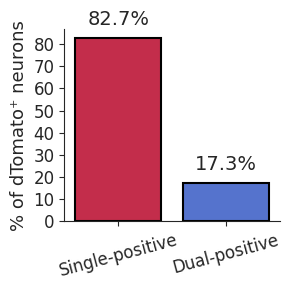

In [29]:
counts = {
    "Single-positive": td_only_neuron.sum(),
    "Dual-positive": dual_hi_neuron.sum(),
}

labels = list(counts.keys())
values = list(counts.values())

# Compute percentages
total = sum(values)
percentages = [(v / total) * 100 for v in values]

plt.figure(figsize=(3, 3))      
sns.set_style("ticks")

ax = sns.barplot(
    x=labels,
    y=percentages,
    palette=["crimson", "royalblue"],
    edgecolor="black",
    linewidth=1.5,
)

# ---- Add percent labels above bars ----
for i, pct in enumerate(percentages):
    ax.text(
        i,
        pct + max(percentages) * 0.05, 
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=14,
    )

# ---- Axis formatting ----
ax.set_ylabel("% of dTomato⁺ neurons", fontsize=13)
ax.set_xlabel("")

# rotate labels a little so they don’t collide
plt.xticks(rotation=15, ha="center", fontsize=12)

ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.tight_layout()
plt.show()

# Export

## Session info

In [ ]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

# Subset to neurons

In [18]:
adata.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  30013
SGC                           24170
CGRP-Gamma                    10396
Nonpeptidergic nociceptors     9901
Mixed                          8352
Vascular_endothelial_1         7669
CGRP-Eta                       6408
Fibroblast_1                   5743
Abeta-RA-LTMR                  5179
Vascular_endothelial_2         4842
TrpM8                          4107
Macrophage_1                   4049
C-LTMR                         3935
Fibroblast_2                   2759
Abeta-Field                    2709
CGRP-Zeta                      2685
Adelta-LTMR                    2661
CGRP-Theta                     2220
Sst                            2208
CGRP-Epsilion                  2110
Pericyte                       1883
CGRP-Alpha                     1643
Proprioceptors                  659
Unassigned                      355
CGRP-Beta                       195
Angiogenic EC                    96
Cycling SGC                      89
Name: count, d

In [19]:
# Define neuron class labels
neuron_labels = {
    "Nonpeptidergic nociceptors",
    "CGRP-Gamma",
    "CGRP-Eta",
    "Abeta-RA-LTMR",
    "CGRP-Alpha",
    "C-LTMR",
    "TrpM8",
    "CGRP-Zeta",
    "Sst",
    "Adelta-LTMR",
    "CGRP-Theta",
    "CGRP-Epsilion",
    "Abeta-Field",
    "Proprioceptors",
    "CGRP-Beta"
}

# Create a new column with “Neuron” or “Non-neuron”
adata.obs["class_seurat"] = np.where(
    adata.obs["seurat_labels"].isin(neuron_labels),
    "Neuron",
    "Non-neuron"
)

In [20]:
adata.obs.class_seurat.value_counts()

class_seurat
Non-neuron    83445
Neuron        63591
Name: count, dtype: int64